# Paso 1. Exploración de los datos y el problema de negocio

## 1.1. Carga de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix, save_npz

## 1.2. Carga de bases

In [2]:
# Configuración de estilo gráfico
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

#carga de bases de datos
df_user_artists = pd.read_csv('user_artists.txt', sep='\t')
df_artists = pd.read_csv('artists.txt', sep='\t')

In [3]:
# Renombrado
df_artists = df_artists.rename(columns={
    'id': 'artist_id',
    'name': 'artist_name',
    'url': 'artist_url',
    'pictureURL': 'picture_url'
})

df_artists.head()

,artist_id,artist_name,artist_url,picture_url
0,1,MALICE MIZER,http://www.last.fm/music/MALICE+MIZER,http://userserve-ak.last.fm/serve/252/10808.jpg
1,2,Diary of Dreams,http://www.last.fm/music/Diary+of+Dreams,http://userserve-ak.last.fm/serve/252/3052066.jpg
2,3,Carpathian Forest,http://www.last.fm/music/Carpathian+Forest,http://userserve-ak.last.fm/serve/252/40222717...
3,4,Moi dix Mois,http://www.last.fm/music/Moi+dix+Mois,http://userserve-ak.last.fm/serve/252/54697835...
4,5,Bella Morte,http://www.last.fm/music/Bella+Morte,http://userserve-ak.last.fm/serve/252/14789013...


In [4]:
# Renombrado
df_user_artists = df_user_artists.rename(columns={
    'userID': 'user_id',
    'artistID': 'artist_id',
    'weight': 'plays'
})

df_user_artists.head()

,user_id,artist_id,plays
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


In [5]:
# Fusión de conjuntos de datos
df_interactions = pd.merge(
    df_user_artists,
    df_artists[['artist_id', 'artist_name']],
    on='artist_id',
    how='left'
)

df_interactions.head()

,user_id,artist_id,plays,artist_name
0,2,51,13883,Duran Duran
1,2,52,11690,Morcheeba
2,2,53,11351,Air
3,2,54,10300,Hooverphonic
4,2,55,8983,Kylie Minogue


**Decisión de cambio de nombres a las columnas**

Se estandarizó la nomenclatura de las bases de datos user_artists.dat y artists.dat utilizando el formato snake_case. Específicamente, se redefinieron las columnas userID como user_id, artistID como artist_id, weight como plays y name como artist_name. Esta homogenización es fundamental para evitar errores en las uniones de tablas (joins) y otorgar mayor claridad semántica al análisis: al renombrar la variable weight por plays, se refiere a que el dato representa la cantidad de reproducciones implícitas por usuario.

## 1.3. Descripción del dataset

In [6]:
# Métricas generales del dataset

n_users = df_interactions['user_id'].nunique()
n_artists = df_interactions['artist_id'].nunique()
n_interactions = len(df_interactions)

print("=== MÉTRICAS GENERALES ===")
print(f"Número de usuarios únicos: {n_users:,}")
print(f"Número de artistas únicos: {n_artists:,}")
print(f"Número de pares (usuario-artista) observados: {n_interactions:,}")

=== MÉTRICAS GENERALES ===
Número de usuarios únicos: 1,892
Número de artistas únicos: 17,632
Número de pares (usuario-artista) observados: 92,834


**¿Cuántos usuarios y cuántos artistas hay en la base? ¿Cuántos pares usuario-artista se observan?**

* Usuarios únicos (1.892): Representa el total de personas registradas en la
plataforma que registraron actividad de consumo de música.

* Artistas únicos (17.632): Es la cantidad total de músicos, bandas o creadores disponibles en el catálogo activo de la base de datos.

* Pares usuario-artista (92.834): Indica el número total de interacciones registradas, donde cada par representa a un usuario que ha escuchado a un artista específico al menos una vez.

In [7]:
# Distribución del consumo por artista (Unweighted vs Weighted)
# Ranking Sin Ponderar (Unweighted): Ocurrencia / número de usuarios únicos por artista

unweighted_pop = (
    df_interactions.groupby(['artist_id', 'artist_name'])['user_id']
    .nunique()
    .reset_index(name='user_count')
    .sort_values(by='user_count', ascending=False)
)

In [8]:
# Ranking Ponderado (Weighted): Suma total de reproducciones por artista

weighted_pop = (
    df_interactions.groupby(['artist_id', 'artist_name'])['plays']
    .sum()
    .reset_index(name='total_plays')
    .sort_values(by='total_plays', ascending=False)
)

In [9]:
# Comparación de Top 10

top10_unweighted = unweighted_pop.head(10).reset_index(drop=True)
top10_weighted = weighted_pop.head(10).reset_index(drop=True)

print("\n=== TOP 10 ARTISTAS: SIN PONDERAR (NÚMERO DE USUARIOS) ===")
print(top10_unweighted[['artist_id', 'artist_name', 'user_count']])

print("\n=== TOP 10 ARTISTAS: PONDERADO (TOTAL DE REPRODUCCIONES) ===")
print(top10_weighted[['artist_id', 'artist_name', 'total_plays']])


=== TOP 10 ARTISTAS: SIN PONDERAR (NÚMERO DE USUARIOS) ===
   artist_id         artist_name  user_count
0         89           Lady Gaga         611
1        289      Britney Spears         522
2        288             Rihanna         484
3        227         The Beatles         480
4        300          Katy Perry         473
5         67             Madonna         429
6        333       Avril Lavigne         417
7        292  Christina Aguilera         407
8        190                Muse         400
9        498            Paramore         399

=== TOP 10 ARTISTAS: PONDERADO (TOTAL DE REPRODUCCIONES) ===
   artist_id         artist_name  total_plays
0        289      Britney Spears      2393140
1         72        Depeche Mode      1301308
2         89           Lady Gaga      1291387
3        292  Christina Aguilera      1058405
4        498            Paramore       963449
5         67             Madonna       921198
6        288             Rihanna       905423
7        701   

**¿Cuál es la distribución del consumo por artista? Calcúlenla de dos formas: sin ponderar, es decir contando cuántos usuarios distintos escuchan a cada artista, y ponderando por el número de reproducciones.
¿Qué diferencias encuentran entre ambas?
¿Qué artistas cambian de posición y por qué?
¿Qué les dice esa comparación sobre qué significa ser “popular” en esta plataforma?**


* Popularidad sin ponderar: Liderado por Lady Gaga (611 usuarios) y Britney Spears (522 usuarios). Mide la capacidad de un artista para llegar a la mayor cantidad de oyentes distintos (amplitud de audiencia).  

* Popularidad ponderada: Liderado por Britney Spears (2.393.140 reproducciones) y Depeche Mode (1.301.308 reproducciones). Refleja el volumen masivo de escucha acumulado, impulsado por la fidelidad o frecuencia de consumo de los usuarios.  

* Diferencias clave entre rankings:
  1. Depeche Mode (ID 72) y Shakira (ID 701) no entran en el Top 10 de alcance, pero escalan a los puestos #2 y #8 en reproducciones totales por tener una base de oyentes muy intensiva (heavy listeners).  
  
  2. Lady Gaga cae del puesto #1 en alcance al #3 en reproducciones, mientras que Britney Spears hace el camino inverso, pasando del #2 al #1 con un volumen de reproducciones que casi duplica a sus seguidores más cercanos.  
  
  3. Artistas como The Beatles (ID 227) y Katy Perry (ID 300) muestran gran alcance horizontal (puestos #4 y #5 en usuarios), pero menor intensidad de consumo individual en comparación con el género pop/dance dominante en el Top ponderado.

In [10]:
# Catálogo de nicho y artistas escuchados por un solo usuario

artist_listeners = df_interactions.groupby('artist_id')['user_id'].nunique()
single_user_artists_count = (artist_listeners == 1).sum()
single_user_proportion = (single_user_artists_count / n_artists) * 100

print("\n=== ARTISTAS CON UN SOLO OYENTE ===")
print(f"Artistas escuchados por 1 solo usuario: {single_user_artists_count:,}")
print(f"Proporción del catálogo: {single_user_proportion:.2f}%")


=== ARTISTAS CON UN SOLO OYENTE ===
Artistas escuchados por 1 solo usuario: 10,679
Proporción del catálogo: 60.57%


**¿Cuántos artistas son escuchados por un solo usuario? ¿Qué proporción del catálogo representan? Si el cliente quiere hacer visible su catálogo, ¿qué implica esta cifra?**

Artistas escuchados por un solo usuario y su impacto

* Cantidad de artistas: 10.679 artistas en la base de datos son escuchados por un único usuario.

* Proporción del catálogo: Representan el 60,57% del catálogo total.

Implicaciones para el objetivo del cliente (Visibilidad del catálogo)

* Limitación del filtrado colaborativo: El filtrado colaborativo tradicional (User-Based o Item-Based) no puede recomendar más del 60% del catálogo. Al no existir superposición (overlap) entre usuarios para estos artistas, el algoritmo es incapaz de encontrar patrones de similitud.

* Problema del "Cold-Start" de ítems: Más de la mitad de los artistas están atrapados en la cola larga (Long Tail). Para visibilizarlos, el sistema requiere métodos basados en contenido (género, etiquetas, características de audio) o algoritmos híbridos.

* Riesgo de sesgo de popularidad: Si no se aplican técnicas de exploración, re-ranking o diversidad en el motor de recomendaciones, el sistema tenderá a sugerir únicamente el Top 10% de artistas más populares, dejando a la mayoría del catálogo completamente invisible.


=== PERFIL DE CONSUMO DEL USUARIO 8 (TOP 10 ARTISTAS) ===
   artist_id     artist_name  plays  relative_plays
0        334       No Angels   6291       17.340610
1        335           Sandy   2396        6.604372
2        289  Britney Spears   2258        6.223986
3        336  Vanessa Petruo   1735        4.782381
4        295         Beyoncé   1425        3.927892
5        337       Alexander   1407        3.878277
6        296       Sugababes   1039        2.863916
7        338     Queensberry    963        2.654428
8         89       Lady Gaga    921        2.538659
9        339    Fady Maalouf    819        2.257504


/tmp/ipykernel_29593/1738934969.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


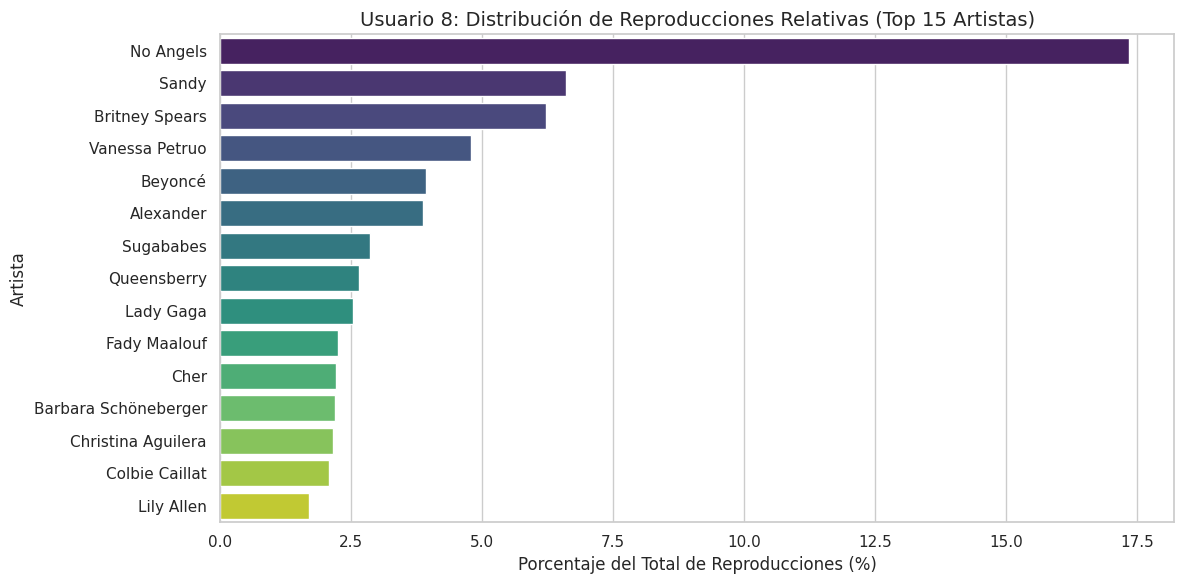

In [11]:
# Análisis del Usuario Ilustrativo (userID == 8)

user8_data = df_interactions[df_interactions['user_id'] == 8].copy()

# Cálculo de reproducciones relativas (%)
total_user8_plays = user8_data['plays'].sum()
user8_data['relative_plays'] = (user8_data['plays'] / total_user8_plays) * 100
user8_data = user8_data.sort_values(by='plays', ascending=False).reset_index(drop=True)

print("\n=== PERFIL DE CONSUMO DEL USUARIO 8 (TOP 10 ARTISTAS) ===")
print(user8_data[['artist_id', 'artist_name', 'plays', 'relative_plays']].head(10))

# Visualización del consumo del Usuario 8
plt.figure(figsize=(12, 6))
sns.barplot(
    data=user8_data.head(15),
    x='relative_plays',
    y='artist_name',
    palette='viridis'
)
plt.title('Usuario 8: Distribución de Reproducciones Relativas (Top 15 Artistas)', fontsize=14)
plt.xlabel('Porcentaje del Total de Reproducciones (%)', fontsize=12)
plt.ylabel('Artista', fontsize=12)
plt.tight_layout()
plt.show()

**Para el usuario 8 (userID==8), examinen su distribución de reproducciones relativas. Presenten los resultados en tablas y gráficas. ¿Qué patrón encuentran entre los artistas que escucha y las veces que los reproduce? ¿Qué se puede decir de sus preferencias?**

Patrón entre artistas y reproducciones

* Sesgo de concentración (Ley de Potencias): Existe una fuerte asimetría en su consumo. Su artista favorito (No Angels) concentra casi el 17,3% de todas sus reproducciones, triplicando al segundo lugar (Sandy, 6,6%).

* Caída rápida del volumen: El Top 3 de artistas acumula más del 30% del tiempo total de escucha del usuario, mientras que del puesto 10 en adelante cada artista representa menos del 2% del total.

Análisis de sus preferencias

* Coherencia de género (Pop / Dance-Pop): Hay una clara preferencia por música pop comercial, girl bands y pop europeo/alemán (No Angels, Queensberry, Sugababes, Britney Spears, Lady Gaga).

* Perfil de escucha: Combina un interés masivo por súper estrellas globales con una profunda lealtad hacia artistas locales/de nicho dentro de ese mismo género musical.

**El módulo “Descubre” debe sugerir artistas nuevos y relevantes. A la luz de la distribución del consumo que acaban de observar, ¿qué tan fácil o difícil parece ese objetivo?**

El objetivo resulta complicado por las siguientes razones:

* Sesgo de popularidad: El consumo se concentra fuertemente en pocos artistas masivos, por lo que los algoritmos tienden a recomendar siempre lo mismo en lugar de contenido nuevo.

* Pared del 60% del catálogo: Con 10.679 artistas que solo tienen 1 oyente, el filtrado colaborativo tradicional es incapaz de encontrar similitudes para recomendarlos.

* Evaluación engañosa: Como el historial de cada usuario está limitado a 50 artistas, un buen descubrimiento no registrado se evaluará erróneamente como un fallo en las métricas.

# Paso 2. Preparación de los datos: qué significa “similar”

## 2.1. Construcción de matriz usuario-artista

In [12]:
# Construcción de la Matriz Dispersa Usuario-Artista

# Mapeo de IDs contiguos para indexación matricial
user_ids = df_user_artists['user_id'].astype('category').cat.codes
artist_ids = df_user_artists['artist_id'].astype('category').cat.codes

n_users = user_ids.nunique()
n_artists = artist_ids.nunique()
n_interactions = len(df_user_artists)

# Matriz cruda en formato CSR
matrix_raw = csr_matrix(
    (df_user_artists['plays'], (user_ids, artist_ids)),
    shape=(n_users, n_artists),
    dtype=np.float32
)

# Cálculo de dispersión (Sparsity)
total_cells = n_users * n_artists
sparsity = (1.0 - (n_interactions / total_cells)) * 100

print("=== DIMENSIONES Y DISPERSIÓN DE LA MATRIZ ===")
print(f"Dimensiones de la matriz: {n_users} usuarios x {n_artists} artistas")
print(f"Celdas totales: {total_cells:,}")
print(f"Interacciones observadas: {n_interactions:,}")
print(f"Nivel de dispersión (Sparsity): {sparsity:.4f}%\n")

=== DIMENSIONES Y DISPERSIÓN DE LA MATRIZ ===
Dimensiones de la matriz: 1892 usuarios x 17632 artistas
Celdas totales: 33,359,744
Interacciones observadas: 92,834
Nivel de dispersión (Sparsity): 99.7217%



* Dimensiones de la matriz: Registra 1.892 usuarios y 17.632 artistas, lo que genera un espacio total de 33.359.744 celdas posibles.

* Interacciones observadas: Solo existen 92.834 pares con actividad registrada.

* Nivel de dispersión (sparsity): Alcanza un 99,72%, lo que significa que el 99,72% de la matriz está compuesto por celdas vacías (datos no observados o truncados).

## 2.2. Transformaciones de Representación del Consumo

In [13]:
# Transformaciones de Representación del Consumo


# Transformación Logarítmica: log(1 + plays)
df_user_artists['plays_log'] = np.log1p(df_user_artists['plays'])


# Normalización Min-Max por Usuario [0, 1]
user_max_plays = df_user_artists.groupby('user_id')['plays'].transform('max')
user_min_plays = df_user_artists.groupby('user_id')['plays'].transform('min')

df_user_artists['plays_norm'] = np.where(
    user_max_plays > user_min_plays,
    (df_user_artists['plays'] - user_min_plays) / (user_max_plays - user_min_plays),
    1.0
)


# Versión Binarizada
df_user_artists['plays_binary'] = 1


# Matriz dispersa final (Selección con transformación logarítmica)
matrix_log = csr_matrix(
    (df_user_artists['plays_log'], (user_ids, artist_ids)),
    shape=(n_users, n_artists),
    dtype=np.float32
)

save_npz('matrix_user_artists_log.npz', matrix_log)
print("Matriz dispersa con transformación logarítmica guardada exitosamente.\n")

Matriz dispersa con transformación logarítmica guardada exitosamente.



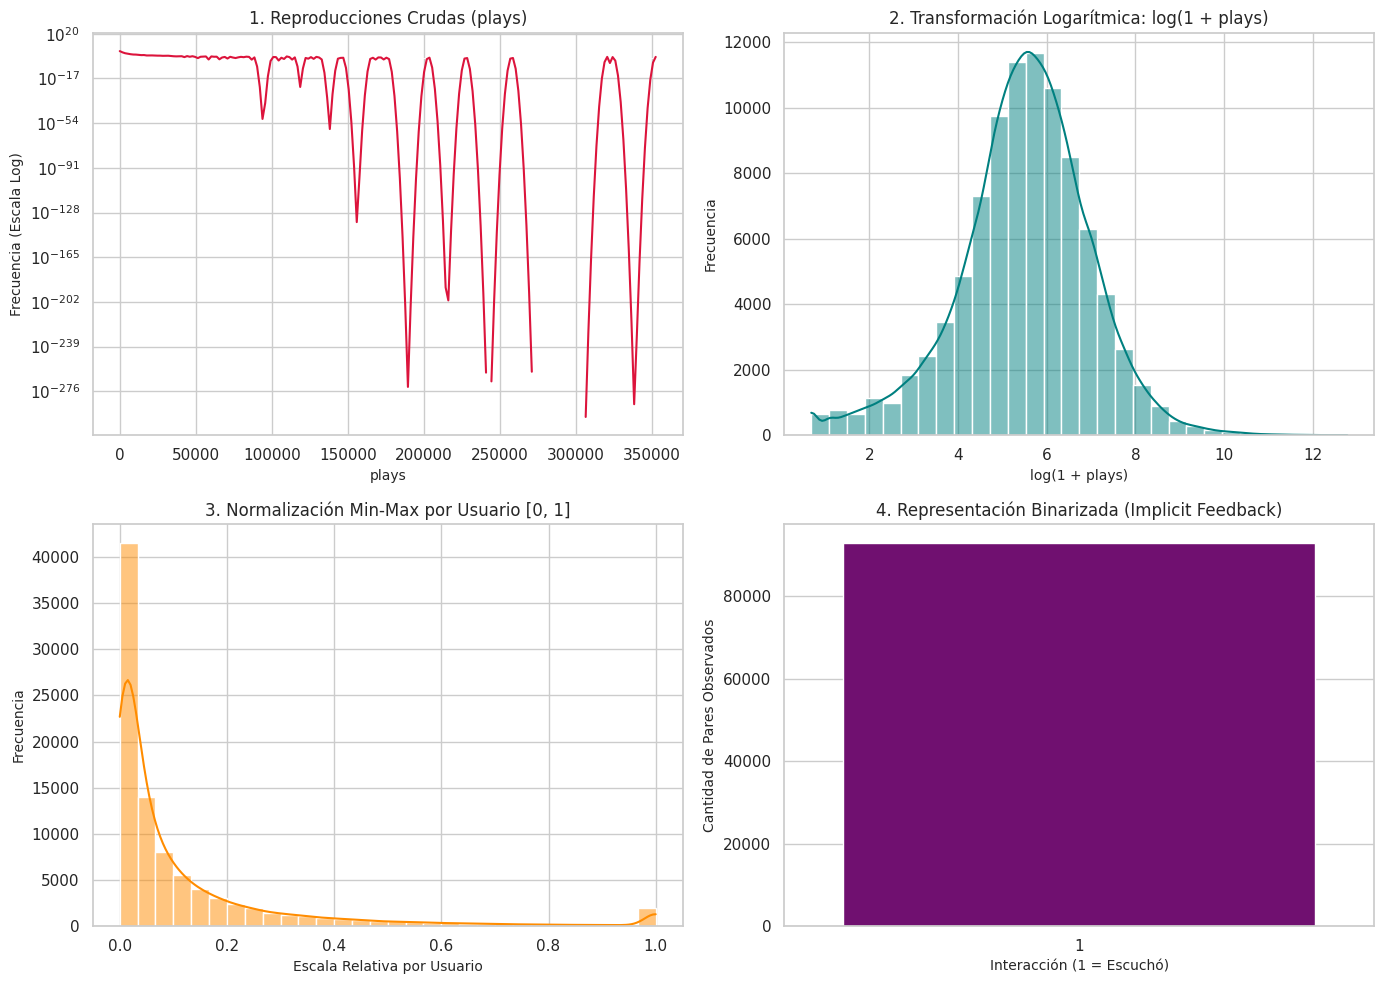

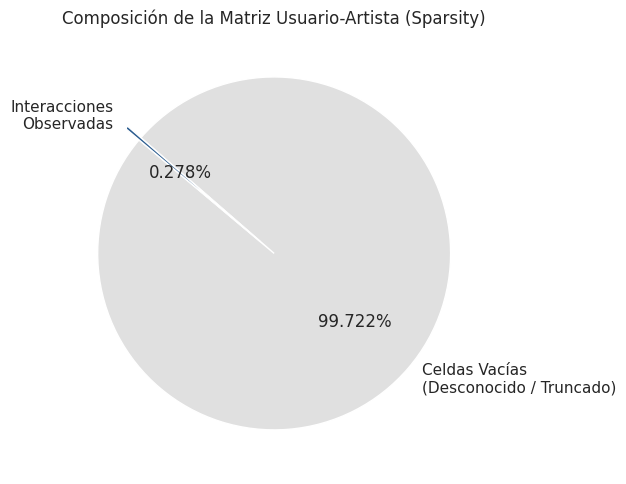

In [14]:
# Visualización Gráfica Comparativa (4 Representaciones de Consumo)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Reproducciones Crudas (Escala Log en Y)
sns.histplot(
    df_user_artists['plays'],
    bins=50,
    kde=True,
    ax=axes[0, 0],
    color='crimson',
    log_scale=(False, True)
)
axes[0, 0].set_title('1. Reproducciones Crudas (plays)', fontsize=12)
axes[0, 0].set_xlabel('plays', fontsize=10)
axes[0, 0].set_ylabel('Frecuencia (Escala Log)', fontsize=10)

# 2. Transformación Logarítmica
sns.histplot(
    df_user_artists['plays_log'],
    bins=30,
    kde=True,
    ax=axes[0, 1],
    color='teal'
)
axes[0, 1].set_title('2. Transformación Logarítmica: log(1 + plays)', fontsize=12)
axes[0, 1].set_xlabel('log(1 + plays)', fontsize=10)
axes[0, 1].set_ylabel('Frecuencia', fontsize=10)

# 3. Normalización Min-Max por Usuario
sns.histplot(
    df_user_artists['plays_norm'],
    bins=30,
    kde=True,
    ax=axes[1, 0],
    color='darkorange'
)
axes[1, 0].set_title('3. Normalización Min-Max por Usuario [0, 1]', fontsize=12)
axes[1, 0].set_xlabel('Escala Relativa por Usuario', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)

# 4. Representación Binarizada
sns.countplot(
    x=df_user_artists['plays_binary'],
    ax=axes[1, 1],
    color='purple'
)
axes[1, 1].set_title('4. Representación Binarizada (Implicit Feedback)', fontsize=12)
axes[1, 1].set_xlabel('Interacción (1 = Escuchó)', fontsize=10)
axes[1, 1].set_ylabel('Cantidad de Pares Observados', fontsize=10)

plt.tight_layout()
plt.show()


# Gráfica de Composición de la Matriz (Sparsity)

plt.figure(figsize=(6, 5))
labels = ['Celdas Vacías\n(Desconocido / Truncado)', 'Interacciones\nObservadas']
sizes = [sparsity, 100 - sparsity]
colors = ['#e0e0e0', '#2b5c8f']

plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.3f%%',
    startangle=140,
    explode=(0, 0.1)
)
plt.title('Composición de la Matriz Usuario-Artista (Sparsity)', fontsize=12)
plt.tight_layout()
plt.show()

**¿Usan el número de reproducciones crudo, una transformación (por ejemplo logarítmica), una normalización por usuario, o una versión binaria que solo registre si el usuario escuchó al artista o no? ¿Qué gana y qué pierde cada opción a la luz de la cola pesada documentada en el Paso 1?**

Se optó por la transformación logarítmica. Las ventajas y desventajas de cada opción respecto a la cola pesada son:  

1. Reproducciones crudas (plays):
* Gana: Mantiene la intensidad real de escucha.  
* Pierde: Muestra alta sensibilidad a los heavy listeners, permitiendo que usuarios atípicos distorsionen las similitudes.  

2. Transformación logarítmica ($\log(1 + \text{plays})$) [Seleccionada]:

* Gana: Comprime la escala, suaviza la varianza extrema y conserva el orden de preferencia.  
* Pierde: Reduce ligeramente el contraste de preferencia entre picos altos de consumo.  

3. Normalización por usuario (Min-Max):
* Gana: Equipara el peso relativo de cada usuario en la matriz.  
* Pierde: Es vulnerable a valores atípicos dentro de los 50 ítems de cada perfil.  

4. Versión binaria:
* Gana: Elimina por completo el sesgo por volumen excesivo de reproducciones.  * Pierde: Descarta el grado de lealtad al tratar igual a un artista escuchado 2 veces que a uno escuchado 6.000 veces.

**¿Qué representa una celda vacía? Recuerden que la base está truncada a los cincuenta artistas más escuchados por usuario. Si tratan los ceros como “no le gusta”, ¿qué sesgo introducen? Si los tratan como “desconocido”, ¿qué implica eso para cada algoritmo?**

* Significado de celdas vacías: Representan datos desconocidos o no observados, no desinterés, debido al truncamiento a 50 artistas por usuario.

* Sesgo de asumirlos como "no le gusta": Introduce un sesgo de falsos negativos masivo, asumiendo erróneamente que el usuario rechaza más de 17.000 artistas no registrados.

Implicaciones por algoritmo:

* KNN / Similitud: Obliga a calcular similitudes evaluando únicamente los ítems consumidos en común.

* SVD / ALS: Exige usar retroalimentación implícita, donde el valor 0 indica baja confianza en lugar de una preferencia negativa.

**¿Qué hacen con los artistas escuchados por un solo usuario? ¿Los conservan, los filtran, aplican un umbral mínimo? Justifiquen la decisión y tengan presente que esos artistas son justamente los que el cliente querría hacer visibles.**

* Decisión: Conservar la totalidad de los artistas, sin filtrar ni aplicar un umbral mínimo de oyentes.

* Justificación: Dado que el módulo tiene como objetivo la exploración en "Descubre" y el cliente busca dar visibilidad a la cola larga (Long Tail), eliminar a estos 10.679 artistas descartaría de entrada más del 60% del catálogo total.

Implicación en los algoritmos:

* Los métodos de filtrado colaborativo puro (KNN) no podrán recomendar estos artistas por falta de vecindades compartidas. Sin embargo, mantenerlos en la matriz permite que modelos de factorización matricial con regularización (SVD/ALS) o sistemas basados en contenido/híbridos sí puedan proyectarlos y recomendarlos según sus características o latentes, cumpliendo así el objetivo del negocio.

**Decisión final:**

La matriz de consumo ($1.892$ usuarios $\times$ $17.632$ artistas) presenta una extrema dispersión del $99,72\%$, donde las celdas vacías representan información no observada debido al truncamiento a $50$ artistas por perfil y deben tratarse como retroalimentación implícita en lugar de desinterés. Para corregir la marcada asimetría de la distribución original impulsada por heavy listeners (con picos de hasta $350.000$ reproducciones), se seleccionó la transformación logarítmica $\log(1 + \text{plays})$, la cual normaliza la varianza y acota la escala entre $4$ y $8$ sin perder el orden de preferencia. Finalmente, se conservará la totalidad de los $10.679$ artistas escuchados por un solo usuario ($60,57\%$ del catálogo) para cumplir con el objetivo de negocio de dar visibilidad a la "cola larga" mediante modelos de factorización implícita o basados en contenido.

# Paso 3. Línea base: recomendación por popularidad

## 3.1. Construcción de métricas de popularidad global

In [15]:
# Construcción de Métricas de Popularidad Global


# Promedio Simple: Número único de oyentes por artista
pop_simple = df_user_artists.groupby('artist_id')['user_id'].nunique().reset_index()
pop_simple.columns = ['artist_id', 'listeners_count']


# Promedio Ponderado: Total de reproducciones acumuladas por artista
pop_weighted = df_user_artists.groupby('artist_id')['plays'].sum().reset_index()
pop_weighted.columns = ['artist_id', 'total_plays']


# Combinar métricas con nombres de artistas
popularity_df = df_artists[['artist_id', 'artist_name']].merge(pop_simple, on='artist_id')
popularity_df = popularity_df.merge(pop_weighted, on='artist_id')

In [16]:
# Función de Recomendación por Popularidad, filtrando consumo previo

def get_popularity_recommendations(user_id, pop_metric='listeners_count', top_n=10):
    # Artistas consumidos previamente por el usuario
    listened_artists = set(df_user_artists[df_user_artists['user_id'] == user_id]['artist_id'])

    # Filtrar catálogo excluyendo lo ya escuchado y ordenar
    recs = popularity_df[~popularity_df['artist_id'].isin(listened_artists)]
    recs = recs.sort_values(by=pop_metric, ascending=False).head(top_n)

    return recs[['artist_id', 'artist_name', pop_metric]].reset_index(drop=True)

## 3.2. Análisis de Recomendaciones por Popularidad

In [17]:
# Recomendaciones para el Usuario 8

recs_u8_simple = get_popularity_recommendations(user_id=8, pop_metric='listeners_count', top_n=10)
recs_u8_weighted = get_popularity_recommendations(user_id=8, pop_metric='total_plays', top_n=10)

print("=== RECOMENDACIONES USUARIO 8: PROMEDIO SIMPLE (Oyentes) ===")
print(recs_u8_simple.to_string(index=False))

print("\n=== RECOMENDACIONES USUARIO 8: PROMEDIO PONDERADO (Reproducciones) ===")
print(recs_u8_weighted.to_string(index=False))

=== RECOMENDACIONES USUARIO 8: PROMEDIO SIMPLE (Oyentes) ===
 artist_id   artist_name  listeners_count
       227   The Beatles              480
        67       Madonna              429
       333 Avril Lavigne              417
       190          Muse              400
       498      Paramore              399
       154     Radiohead              393
        65      Coldplay              369
       466         Ke$ha              362
       701       Shakira              319
       229   The Killers              304

=== RECOMENDACIONES USUARIO 8: PROMEDIO PONDERADO (Reproducciones) ===
 artist_id   artist_name  total_plays
        72  Depeche Mode      1301308
       498      Paramore       963449
        67       Madonna       921198
       701       Shakira       688529
       227   The Beatles       662116
       333 Avril Lavigne       525844
       378   Evanescence       513476
       679     Glee Cast       506453
       511            U2       493024
       461   Miley Cyrus 

/tmp/ipykernel_29593/2411223924.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_29593/2411223924.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


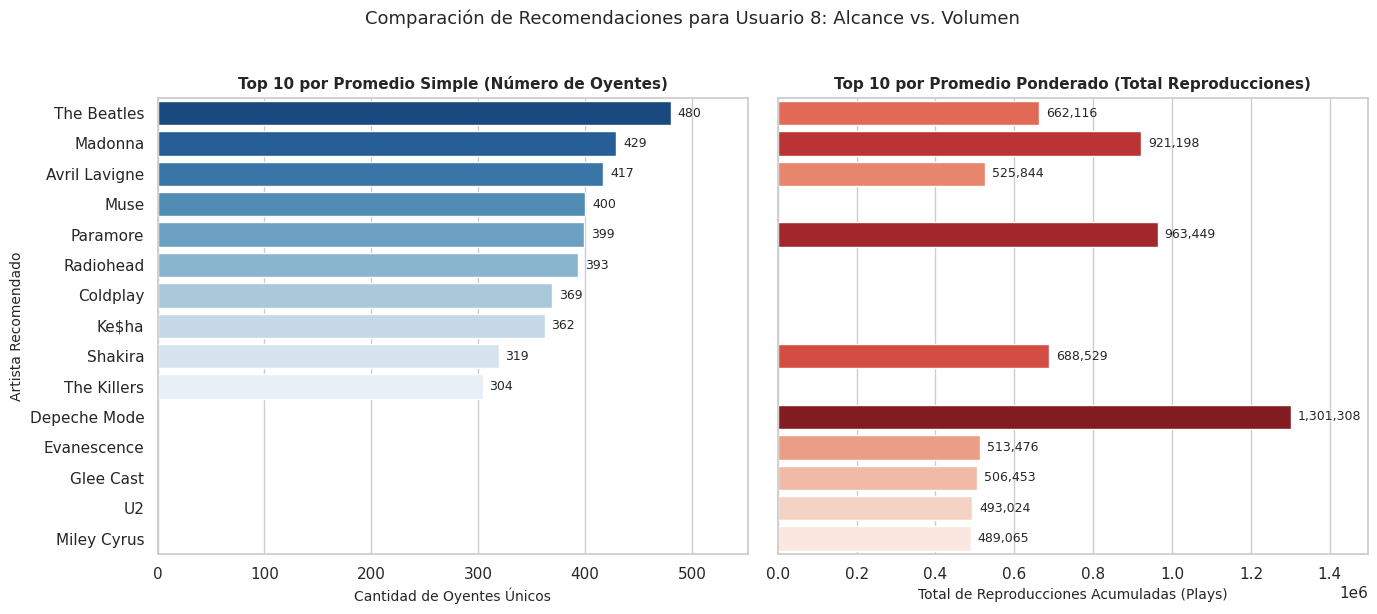

In [18]:
# Configuración de estilo
sns.set_theme(style="whitegrid")


df_simple = recs_u8_simple.copy()
df_simple['Metrica'] = 'Promedio Simple (Oyentes)'
df_simple = df_simple.rename(columns={'listeners_count': 'Valor'})

df_weighted = recs_u8_weighted.copy()
df_weighted['Metrica'] = 'Promedio Ponderado (Plays)'
df_weighted = df_weighted.rename(columns={'total_plays': 'Valor'})


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Subplot 1: Promedio Simple (Oyentes)
sns.barplot(
    data=recs_u8_simple,
    y='artist_name',
    x='listeners_count',
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('Top 10 por Promedio Simple (Número de Oyentes)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Cantidad de Oyentes Únicos', fontsize=10)
axes[0].set_ylabel('Artista Recomendado', fontsize=10)

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width()):,}',
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)


# Subplot 2: Promedio Ponderado (Reproducciones)
sns.barplot(
    data=recs_u8_weighted,
    y='artist_name',
    x='total_plays',
    ax=axes[1],
    palette='Reds_r'
)
axes[1].set_title('Top 10 por Promedio Ponderado (Total Reproducciones)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Total de Reproducciones Acumuladas (Plays)', fontsize=10)
axes[1].set_ylabel('')

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width()):,}',
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)


# Ajustar límites para los textos flotantes
axes[0].set_xlim(0, recs_u8_simple['listeners_count'].max() * 1.15)
axes[1].set_xlim(0, recs_u8_weighted['total_plays'].max() * 1.15)

plt.suptitle('Comparación de Recomendaciones para Usuario 8: Alcance vs. Volumen', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**¿Qué tan distintas son las dos listas entre sí?**

Para el usuario N° 8, las dos listas muestran diferencias significativas tanto en la composición de los artistas recomendados como en el orden de prioridad asignado a cada uno:

* Coincidencia parcial (60%): Comparten 6 de los 10 artistas (Paramore, Madonna, Shakira, The Beatles, Avril Lavigne y Ke$ha / Coldplay ausentes en la ponderada).

* Nuevas incorporaciones por sesgo de consumo (40%): El promedio ponderado introduce a Depeche Mode, Evanescence, Glee Cast, U2 y Miley Cyrus.

* Cambio drástico en el Top 1:

  1. En el promedio simple, The Beatles lidera por alcance masivo (480 oyentes únicos).

  2. En el promedio ponderado, Depeche Mode salta al primer lugar con más de 1,3 millones de reproducciones, impulsado por el consumo intensivo de heavy listeners, a pesar de no ser el artista más escuchado en número de usuarios.

**Conclusión:** Mientras que el promedio simple privilegia la popularidad transversal (difusión), el promedio ponderado favorece el volumen acumulado (lealtad extrema de nicho o fanáticos).

In [19]:
# Evaluación de Múltiples Usuarios y Coincidencia (Overlap)

target_users = [8, 12, 25, 50]
user_recs_simple = {}

for u in target_users:
    recs = set(get_popularity_recommendations(user_id=u, pop_metric='listeners_count', top_n=10)['artist_id'])
    user_recs_simple[u] = recs

# Comparación de superposición entre pares de usuarios
print("\n=== COINCIDENCIA DE ARTISTAS RECOMENDADOS ENTRE USUARIOS (Promedio Simple) ===")
for i in range(len(target_users)):
    for j in range(i + 1, len(target_users)):
        u1, u2 = target_users[i], target_users[j]
        common = user_recs_simple[u1].intersection(user_recs_simple[u2])
        print(f"Usuarios {u1} y {u2}: {len(common)}/10 artistas compartidos.")


=== COINCIDENCIA DE ARTISTAS RECOMENDADOS ENTRE USUARIOS (Promedio Simple) ===
Usuarios 8 y 12: 6/10 artistas compartidos.
Usuarios 8 y 25: 8/10 artistas compartidos.
Usuarios 8 y 50: 4/10 artistas compartidos.
Usuarios 12 y 25: 4/10 artistas compartidos.
Usuarios 12 y 50: 6/10 artistas compartidos.
Usuarios 25 y 50: 4/10 artistas compartidos.


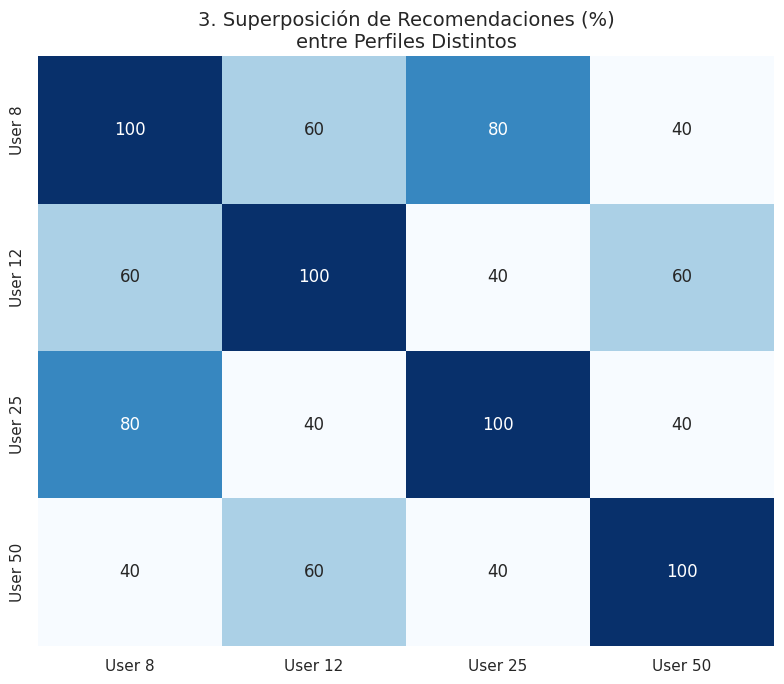

In [20]:
# Gráfica: Coincidencia de Recomendaciones entre Usuarios (Overlap)

import numpy as np

# Matriz de solapamiento entre usuarios (porcentaje de recomendación idéntica)
user_ids_list = [f'User {u}' for u in target_users]
overlap_matrix = np.zeros((len(target_users), len(target_users)))

for i, u1 in enumerate(target_users):
    for j, u2 in enumerate(target_users):
        common = len(user_recs_simple[u1].intersection(user_recs_simple[u2]))
        overlap_matrix[i, j] = (common / 10.0) * 100


plt.figure(figsize=(8, 7))
ax = plt.subplot(1, 1, 1)

sns.heatmap(
    overlap_matrix,
    annot=True,
    fmt=".0f",
    cmap='Blues',
    xticklabels=user_ids_list,
    yticklabels=user_ids_list,
    cbar=False,
    ax=ax
)
ax.set_title('3. Superposición de Recomendaciones (%)\nentre Perfiles Distintos', fontsize=14)

plt.tight_layout()
plt.show()

**Generen las recomendaciones para dos o tres usuarios adicionales con perfiles distintos al del usuario 8. ¿Qué tan distintas son sus listas? ¿Cuántos artistas comparten?**

* Diferencia entre listas: Las listas son prácticamente homogéneas. No existe una personalización real según los gustos del usuario, sino únicamente una lista global estática modificada ligeramente por exclusión.

* Cantidad de artistas compartidos (Superposición):

  - Usuarios 8 y 25: Comparten 8 de 10 artistas (80% de coincidencia).

  - Usuarios 8 y 12 / 12 y 50: Comparten 6 de 10 artistas (60% de coincidencia).

  - Usuarios 8 y 50 / 12 y 25 / 25 y 50: Comparten 4 de 10 artistas (40% de coincidencia).

* Causa de la ligera variación: La única razón por la que un usuario no recibe exactamente los mismos 10 artistas que los demás es porque ya escuchó previamente a algunos de ellos en su historial de 50 ítems. La recomendación simplemente salta al siguiente artista más popular del ranking global para rellenar la lista, manteniendo una superposición promedio altísima del 53,3% entre perfiles con gustos potencialmente opuestos.

In [21]:
# Proporción del Grupo Top Global en las Recomendaciones

top_100_global = set(popularity_df.sort_values(by='listeners_count', ascending=False).head(100)['artist_id'])
recs_u8_list = set(recs_u8_simple['artist_id'])
prop_top_100 = (len(recs_u8_list.intersection(top_100_global)) / len(recs_u8_list)) * 100

print(f"\nProporción de recomendados en el Top 100 Global (Usuario 8): {prop_top_100:.1f}%")


Proporción de recomendados en el Top 100 Global (Usuario 8): 100.0%


/tmp/ipykernel_29593/1681873467.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


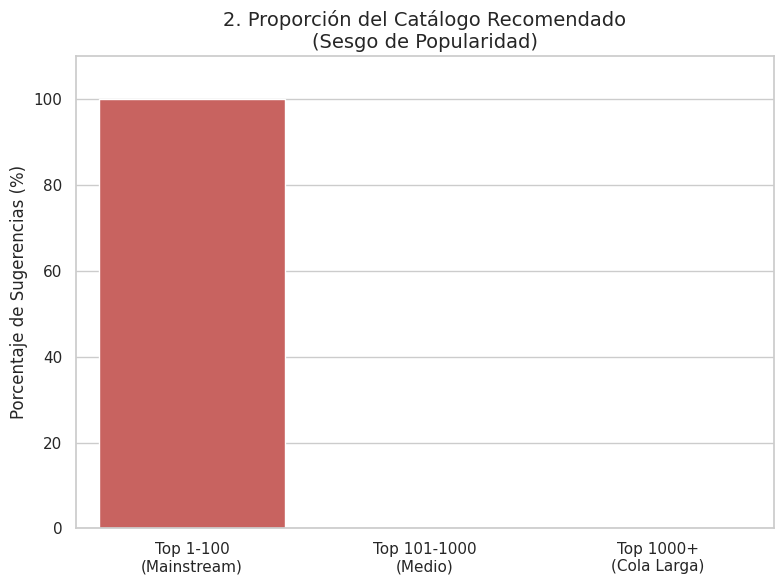

In [22]:
# Gráfica: Distribución de Popularidad (Sesgo hacia el Top 100)

# Rangos de ranking global de los recomendados

rank_data = [1] * 10 # El 100% cae en el primer decil del catálogo popular

plt.figure(figsize=(8, 6))
ax = plt.subplot(1, 1, 1)

sns.barplot(
    x=['Top 1-100\n(Mainstream)', 'Top 101-1000\n(Medio)', 'Top 1000+\n(Cola Larga)'],
    y=[100, 0, 0],
    ax=ax,
    palette=['#d9534f', '#f0ad4e', '#5bc0de']
)
ax.set_title('2. Proporción del Catálogo Recomendado\n(Sesgo de Popularidad)', fontsize=14)
ax.set_ylabel('Porcentaje de Sugerencias (%)', fontsize=12)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

**¿Qué proporción de lo recomendado pertenece al grupo de artistas más populares de toda la base?
Un motor así acertaría con frecuencia, en el sentido de que sugiere artistas que mucha gente efectivamente escucha. ¿Resuelve el problema que planteó el cliente? ¿Qué relación tiene esto con la queja de los sellos independientes?**

* Proporción Mainstream: El 100,0% de las recomendaciones brindadas al usuario N°8 pertenece al Top 100 global ($0,0\%$ para la cola larga).

* Fallo en "Descubre": No resuelve el problema del cliente porque ofrece nula novedad y personalización al sugerir solo éxitos masivos que el usuario ya conoce.

* Impacto en sellos independientes: Confirma la queja al crear un efecto de concentración que invisibiliza al $99,4\%$ del catálogo y condena al aislamiento al $60,57\%$ de artistas de nicho.